# Pani et al. (2022) PCA Analysis Workflow

This notebook demonstrates the usage of the `PaniEtAlPCA` class to perform PCA based on the methodology from Pani et al. (2022).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Make sure the analysis module is in the path
import sys
sys.path.append('..')

from population_analysis.pani_pca import PaniEtAlPCA

%matplotlib inline

## 1. Configuration and Initialization

First, we define the configuration for the analysis and initialize the `PaniEtAlPCA` class.

In [2]:
config = {
    'epok': [-100, 200], 
    'bin_size': 1, 
    'n_pca_components': 5,
    'n_initial_pca_components': 3, # For the Pani method
    'n_rt_groups': 5 # Fewer groups for demonstration
}

analyzer = PaniEtAlPCA(config)
print("Analyzer initialized with the following configuration:")
print(analyzer.config)

Analyzer initialized with the following configuration:
{'monkey': 'fiona', 'excluded_sessions': ['fi210628', 'fi210629', 'fi210704'], 'epok': [-100, 200], 'bin_size': 1, 'delta': False, 'alignment_point': 'go_cue', 'smooth_ker_size': 25, 'normalize': 'by_baseline_FR', 'n_pca_components': 5, 'subtract_average_PSTH': True, 'ssd_number': 1, 'min_cells_per_session': 10, 'min_trials_per_condition': 5, 'required_trial_types': ['GO', 'STOP', 'CONT'], 'required_directions': [0, 180], 'figsize_3d': (12, 10), 'figsize_2d_grid': (7, 19), 'figsize_time': (10, 3), 'n_workers': 6, 'n_rt_groups': 5, 'n_initial_pca_components': 3, 'hpa_fit_time_window': [0, 300]}


## 2. Load Data and Validate Sessions

We use the methods inherited from `MultiSessionPCA` to load the data and identify valid sessions for analysis.

In [3]:
DATA_PATH = Path('../data/unified_cell_trial_data/msn_fiona_cell_trial_data.pkl')

analyzer.load_data(DATA_PATH)
analyzer.validate_all_sessions(verbose=False) # verbose=False to keep output clean

print(f"Found {analyzer.n_sessions} valid sessions.")

Loading data from: ../data/unified_cell_trial_data/msn_fiona_cell_trial_data.pkl
✓ Database loaded: 770,705 cell-trial combinations
  Total sessions: 60
  Total unique cells: 1414
✓ Session statistics computed for 60 sessions
  Excluded sessions: 1
  Candidate sessions: 59
Cell 2134 removed from session fi211110a.
Dropped 1 cell with incomplete trial type or directional data.
Found 40 valid sessions.


## 3. Fit the Pani et al. PCA Model

This is the main step where the new logic is applied. The `fit_pani_pca` method will perform the grouped PSTH extraction, initial PCA, and identification of the HPA and PEA.

**Note**: The current implementation contains placeholder logic. This cell demonstrates the intended workflow.

In [4]:
# This method will eventually contain the full logic.
# It would internally call a method like `extract_grouped_psth` for all valid sessions.
analyzer.fit_pani_pca()

Extracting grouped PSTHs from 40 sessions...


Processing Sessions: 100%|██████████| 40/40 [00:44<00:00,  1.12s/it]

✓ Grouped PSTH extraction complete.
Running Pani et al. PCA on session: fi211110a
Performing initial PCA with 3 components...
Identifying holding plane from correct-stop trials...
Defining HPA and PEA...
✓ Pani et al. PCA model fitted.


## 4. Visualize the Results

Once the model is fitted, we can use the new plotting methods to visualize the results in the context of the HPA and PEA.

Plotting HPA and PEA projections...
Plotting HPA/PEA projections for session fi211110a...


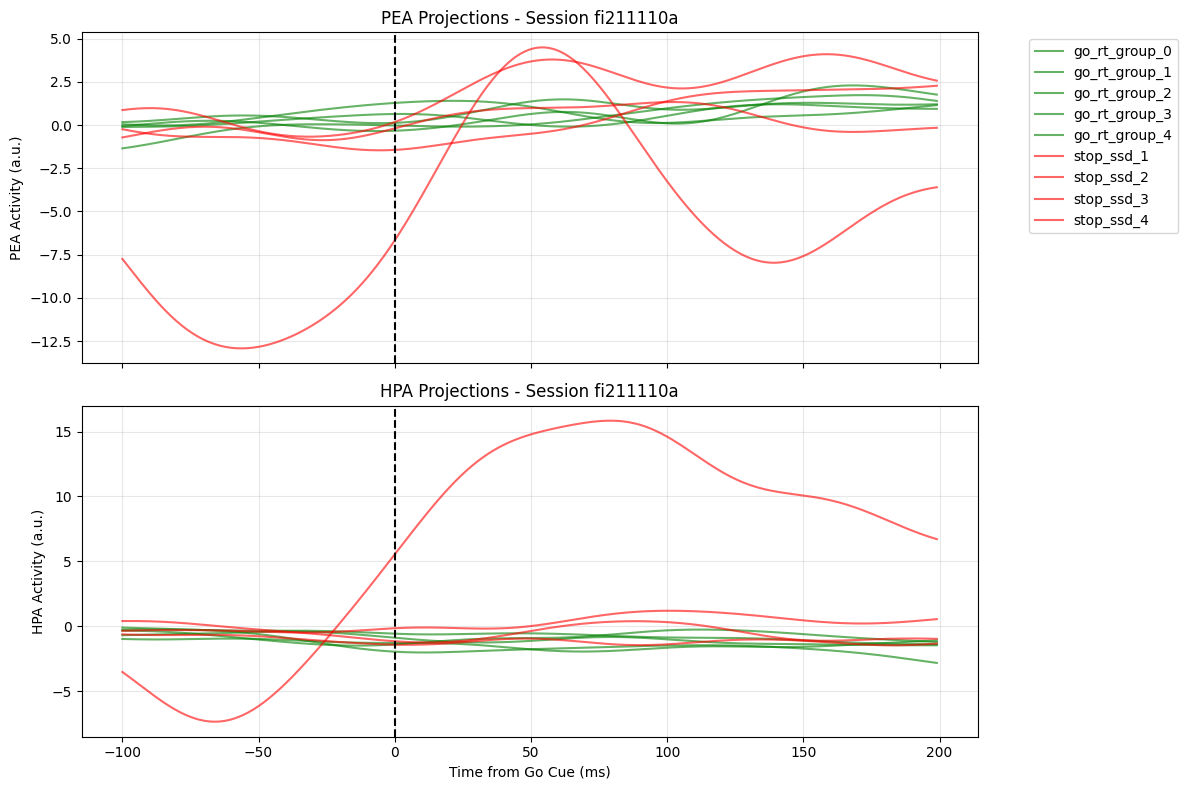

In [5]:
print("Plotting HPA and PEA projections...")
fig1, axes1 = analyzer.plot_hpa_pea_projections(show=True)

Plotting 3D trajectories with HPA and PEA...
Plotting 3D trajectories for session fi211110a...


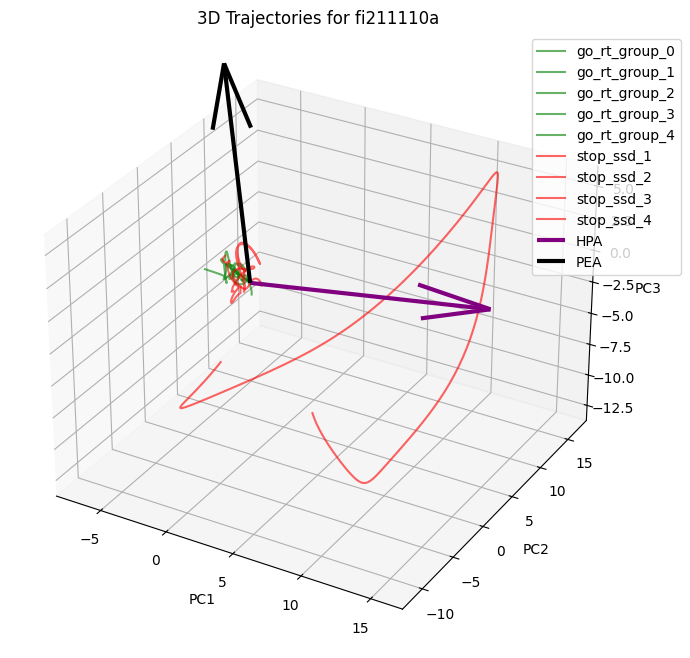

In [6]:
print("Plotting 3D trajectories with HPA and PEA...")
fig2, ax2 = analyzer.plot_3d_trajectories_with_axes(show=True)

## Next Steps

The next step is to fully implement the logic within the `PaniEtAlPCA` class, particularly:

1.  `extract_grouped_psth()`: To perform the detailed trial grouping and PSTH extraction.
2.  `fit_pani_pca()`: To implement the SVD-based identification of the holding plane and the subsequent definition of HPA and PEA.